# Hard GIPCA (Method A) - Simulation Study

This notebook tests the **Hard GIPCA** model on simulated data.

In the Hard GIPCA model, factors are fully determined by the macro state:
$$f_t \equiv \Lambda' m_t$$

The objective function is:
$$\min_{\Gamma, \Lambda} \frac{1}{N} \sum_t \|x_t - Z_t \Gamma (\Lambda' m_t)\|^2 \quad \text{s.t.} \quad \Gamma'\Gamma = I_K$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

# Add src to path
sys.path.insert(0, '../src')

from hard_gipca import HardGIPCA

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Generate Simulated Data

We simulate data following the Hard GIPCA DGP:
- **Returns**: $r_{i,t} = c_{i,t}' \Gamma f_t + \epsilon_{i,t}$
- **Factors**: $f_t = \Lambda' m_t$ (deterministic given macro)

In [2]:
# Set simulation parameters
np.random.seed(42)

T = 120    # time periods (e.g., 10 years of monthly data)
N = 100    # number of assets
L = 8      # number of characteristics
K = 3      # number of factors
R = 4      # number of macro variables (not counting intercept)

print(f"Simulation Parameters:")
print(f"  Time periods (T):      {T}")
print(f"  Assets (N):            {N}")
print(f"  Characteristics (L):   {L}")
print(f"  Factors (K):           {K}")
print(f"  Macro variables (R):   {R} + 1 intercept = {R+1} total")

Simulation Parameters:
  Time periods (T):      120
  Assets (N):            100
  Characteristics (L):   8
  Factors (K):           3
  Macro variables (R):   4 + 1 intercept = 5 total


In [3]:
# Generate true parameters
# True Gamma: L x K, orthonormal columns
true_Gamma = np.random.randn(L, K)
true_Gamma, _ = np.linalg.qr(true_Gamma)
true_Gamma = true_Gamma[:, :K]

# True Lambda: (R+1) x K (includes intercept)
true_Lambda = np.random.randn(R + 1, K) * 0.5

print(f"True Gamma shape: {true_Gamma.shape}")
print(f"True Lambda shape: {true_Lambda.shape}")
print(f"\nGamma orthonormality check (Gamma'Gamma):")
print(np.round(true_Gamma.T @ true_Gamma, 4))

True Gamma shape: (8, 3)
True Lambda shape: (5, 3)

Gamma orthonormality check (Gamma'Gamma):
[[ 1.  0. -0.]
 [ 0.  1.  0.]
 [-0.  0.  1.]]


Macro matrix M shape: (120, 5)


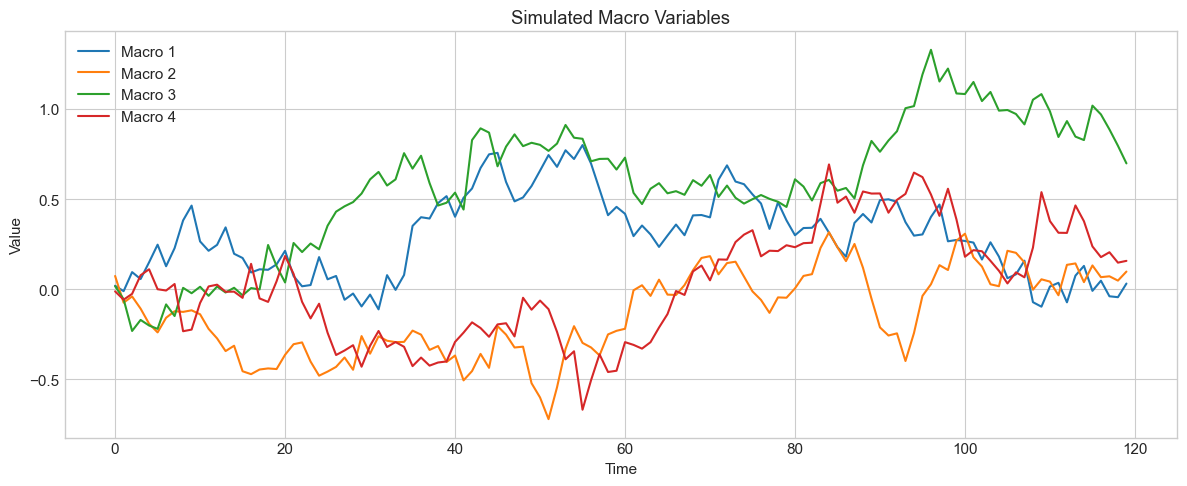

In [4]:
# Generate macro variables (persistent AR(1) processes)
M_raw = np.cumsum(np.random.randn(T, R) * 0.1, axis=0)
# Prepend intercept column
M = np.column_stack([np.ones(T), M_raw])  # T x (R+1)
R_total = R + 1

print(f"Macro matrix M shape: {M.shape}")

# Plot macro variables
fig, ax = plt.subplots(figsize=(12, 5))
for r in range(1, R_total):  # Skip intercept
    ax.plot(M[:, r], label=f'Macro {r}')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.set_title('Simulated Macro Variables')
ax.legend()
plt.tight_layout()
plt.show()

True factors shape: (120, 3)


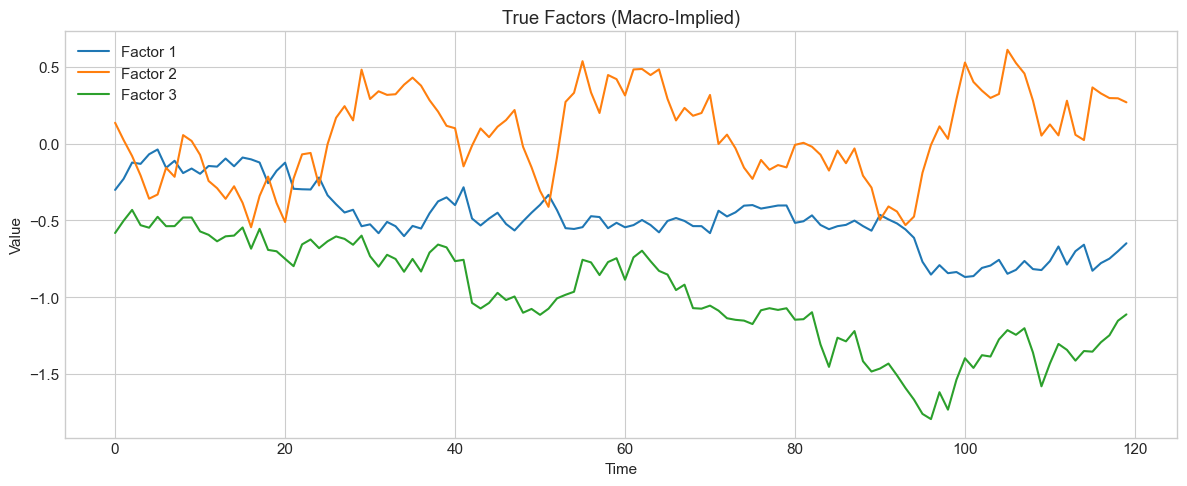

In [5]:
# Generate true factors: f_t = Lambda' m_t (hard DGP)
true_factors = M @ true_Lambda  # T x K

print(f"True factors shape: {true_factors.shape}")

# Plot true factors
fig, ax = plt.subplots(figsize=(12, 5))
for k in range(K):
    ax.plot(true_factors[:, k], label=f'Factor {k+1}')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.set_title('True Factors (Macro-Implied)')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Generate characteristics Z (T x N x L)
Z = np.random.randn(T, N, L) * 0.5
# First characteristic is an intercept
Z[:, :, 0] = 1.0

print(f"Characteristics Z shape: {Z.shape}")

Characteristics Z shape: (120, 100, 8)


In [7]:
# Generate returns: r_{i,t} = c_{i,t}' Gamma f_t + epsilon
noise_std = 0.5
rets = np.zeros((T, N))

for t in range(T):
    loadings = Z[t, :, :] @ true_Gamma  # N x K
    rets[t, :] = loadings @ true_factors[t, :] + np.random.randn(N) * noise_std

print(f"Returns shape: {rets.shape}")
print(f"\nReturns statistics:")
print(f"  Mean: {np.mean(rets):.4f}")
print(f"  Std:  {np.std(rets):.4f}")
print(f"  Min:  {np.min(rets):.4f}")
print(f"  Max:  {np.max(rets):.4f}")

Returns shape: (120, 100)

Returns statistics:
  Mean: -0.2520
  Std:  0.7780
  Min:  -3.8619
  Max:  4.0919


In [8]:
# Package data
data = [rets, Z, M]

print("Data prepared for HardGIPCA:")
print(f"  rets: {data[0].shape}")
print(f"  Z:    {data[1].shape}")
print(f"  M:    {data[2].shape}")

Data prepared for HardGIPCA:
  rets: (120, 100)
  Z:    (120, 100, 8)
  M:    (120, 5)


## 2. Fit the Hard GIPCA Model

In [9]:
# Initialize the model
model = HardGIPCA(
    num_assets=N,
    num_fact=K,
    num_charact=L,
    num_macro=R_total,
    win_len=T,
    ridge=1e-8
)

print("HardGIPCA model initialized")
print(f"  K (factors):        {model.K}")
print(f"  L (characteristics):{model.L}")
print(f"  R (macro vars):     {model.R}")

HardGIPCA model initialized
  K (factors):        3
  L (characteristics):8
  R (macro vars):     5


In [10]:
# Fit the model
Gamma_est, history = model.fit(
    data, 
    max_iter=500, 
    tol=1e-6,
    verbose=True, 
    seed=42
)

Iteration    0: Objective = 34.151908


Iteration   10: Objective = 29.741783, Max change = 1.15e-04



Converged after 15 iterations
Initial objective: 34.151908
Final objective:   29.741783
Reduction:         12.91%


In [11]:
# Get results
results = model.get_results()

print("\nEstimation Results:")
print(f"  Gamma shape:   {results['Gamma'].shape}")
print(f"  Lambda shape:  {results['Lambda'].shape}")
print(f"  Factors shape: {results['factors'].shape}")
print(f"  Iterations:    {results['n_iterations']}")


Estimation Results:
  Gamma shape:   (8, 3)
  Lambda shape:  (5, 3)
  Factors shape: (3, 120)
  Iterations:    15


## 3. Convergence Analysis

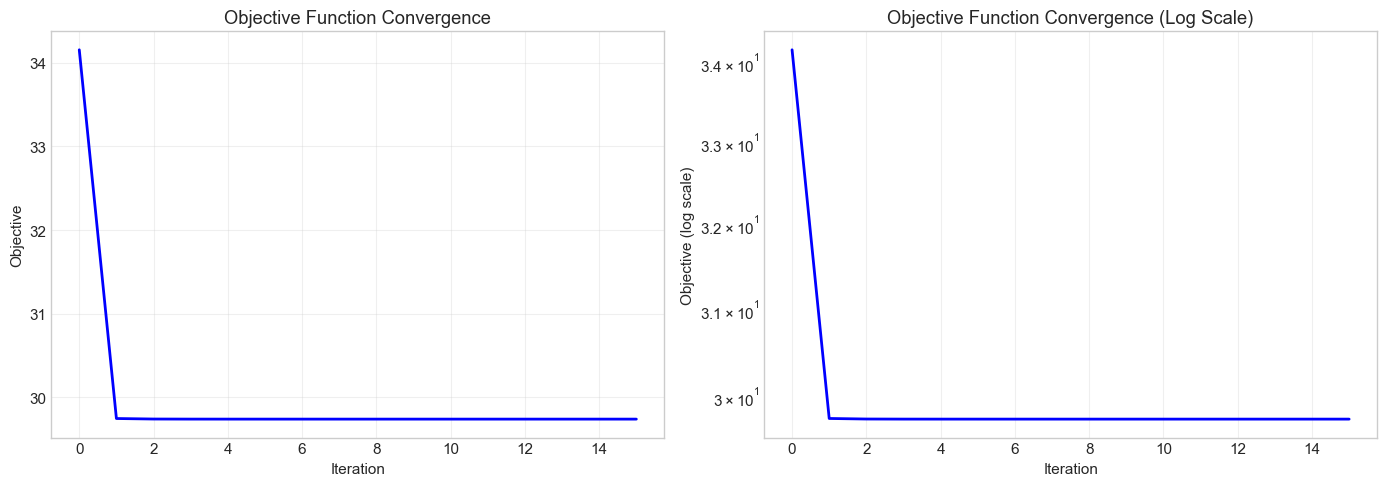

Objective monotonicity: PASS


In [12]:
# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Objective function
ax = axes[0]
ax.plot(history, 'b-', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Objective')
ax.set_title('Objective Function Convergence')
ax.grid(True, alpha=0.3)

# Log scale
ax = axes[1]
ax.semilogy(history, 'b-', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Objective (log scale)')
ax.set_title('Objective Function Convergence (Log Scale)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check monotonicity
diffs = np.diff(history)
n_increases = np.sum(diffs > 1e-10)
print(f"Objective monotonicity: {'PASS' if n_increases == 0 else f'FAIL ({n_increases} increases)'}")

## 4. Model Evaluation

In [13]:
# Compute R-squared
r2 = model.score(data)
print(f"Overall R-squared: {r2:.4f}")

Overall R-squared: 0.5906


In [14]:
# Subspace comparison: True vs Estimated Gamma
Q1, _ = np.linalg.qr(true_Gamma)
Q2, _ = np.linalg.qr(Gamma_est)
_, s, _ = np.linalg.svd(Q1.T @ Q2)
principal_angles = np.arccos(np.clip(s, -1, 1))

print("Subspace Comparison (True vs Estimated Gamma):")
print(f"  Principal angles (degrees): {np.round(np.degrees(principal_angles), 2)}")
print(f"  Grassmann distance:         {np.linalg.norm(principal_angles):.4f}")

Subspace Comparison (True vs Estimated Gamma):
  Principal angles (degrees): [ 0.76  5.75 39.13]
  Grassmann distance:         0.6904


In [15]:
# Factor correlation with true factors
est_factors = results['factors'].values  # K x T
factor_corr = np.corrcoef(est_factors, true_factors.T)[:K, K:]

print("Factor Correlations (|correlation| with true factors):")
print(np.round(np.abs(factor_corr), 4))
print(f"\nMean absolute correlation: {np.mean(np.abs(np.diag(factor_corr))):.4f}")

Factor Correlations (|correlation| with true factors):
[[0.8976 0.8835 0.4677]
 [0.6126 0.2492 0.9665]
 [0.9864 0.72   0.6824]]

Mean absolute correlation: 0.6097


## 5. Visualize Estimated Parameters

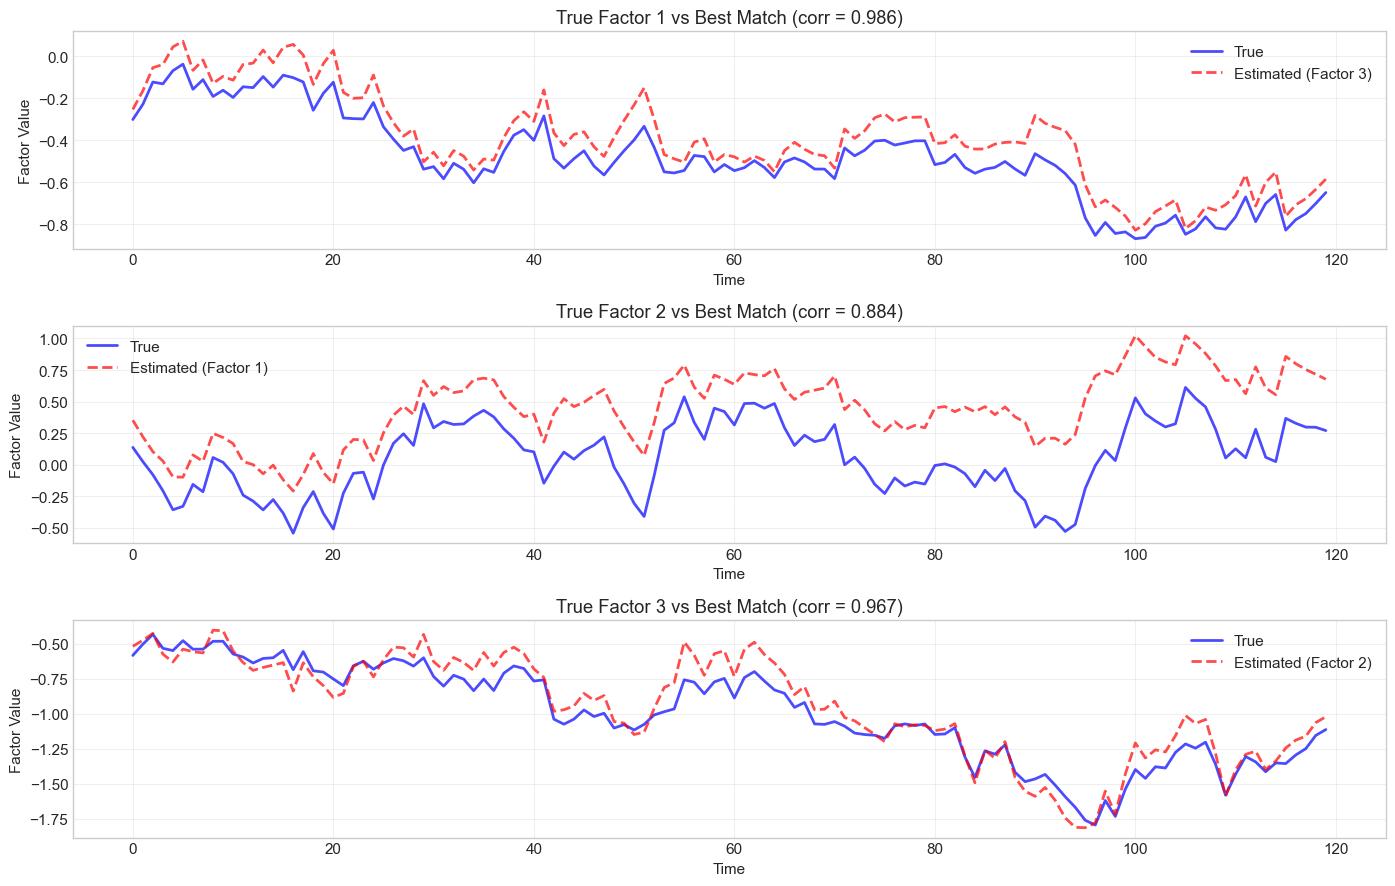

In [16]:
# Plot estimated factors vs true factors
fig, axes = plt.subplots(K, 1, figsize=(14, 3*K))
if K == 1:
    axes = [axes]

for k in range(K):
    ax = axes[k]
    ax.plot(true_factors[:, k], 'b-', label='True', linewidth=2, alpha=0.7)
    
    # Find best matching estimated factor
    best_corr = 0
    best_idx = 0
    for j in range(K):
        corr = np.abs(np.corrcoef(true_factors[:, k], est_factors[j, :])[0, 1])
        if corr > best_corr:
            best_corr = corr
            best_idx = j
    
    # Align sign
    sign = np.sign(np.corrcoef(true_factors[:, k], est_factors[best_idx, :])[0, 1])
    ax.plot(sign * est_factors[best_idx, :], 'r--', label=f'Estimated (Factor {best_idx+1})', linewidth=2, alpha=0.7)
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Factor Value')
    ax.set_title(f'True Factor {k+1} vs Best Match (corr = {best_corr:.3f})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

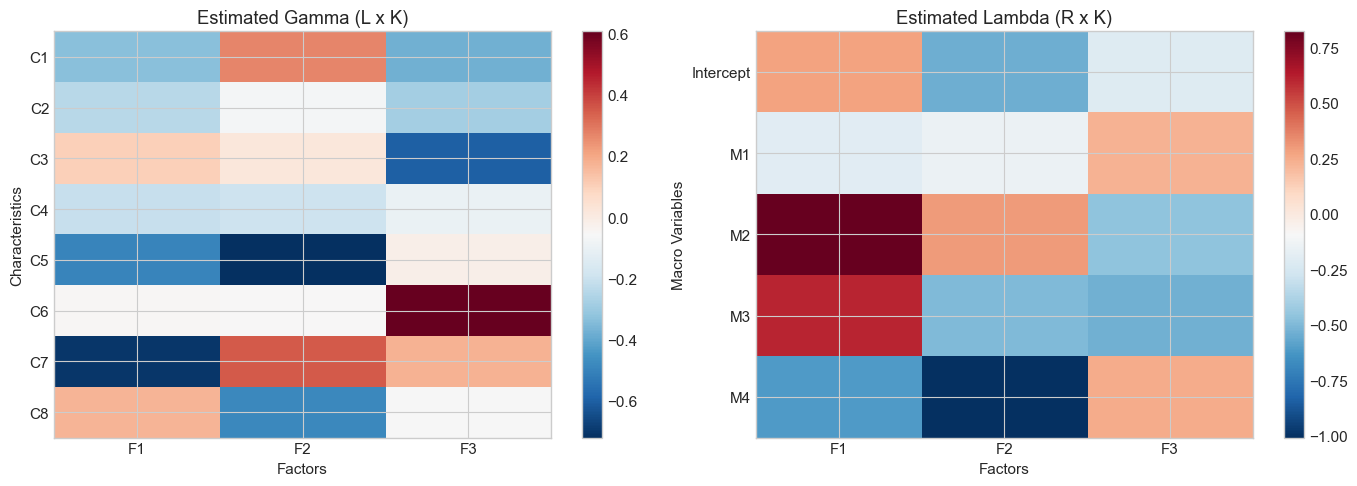

In [17]:
# Heatmaps of Gamma and Lambda
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gamma heatmap
ax = axes[0]
im = ax.imshow(results['Gamma'].values, aspect='auto', cmap='RdBu_r')
ax.set_xlabel('Factors')
ax.set_ylabel('Characteristics')
ax.set_title('Estimated Gamma (L x K)')
ax.set_xticks(range(K))
ax.set_xticklabels([f'F{k+1}' for k in range(K)])
ax.set_yticks(range(L))
ax.set_yticklabels([f'C{l+1}' for l in range(L)])
plt.colorbar(im, ax=ax)

# Lambda heatmap
ax = axes[1]
im = ax.imshow(results['Lambda'].values, aspect='auto', cmap='RdBu_r')
ax.set_xlabel('Factors')
ax.set_ylabel('Macro Variables')
ax.set_title('Estimated Lambda (R x K)')
ax.set_xticks(range(K))
ax.set_xticklabels([f'F{k+1}' for k in range(K)])
ax.set_yticks(range(R_total))
ax.set_yticklabels(['Intercept'] + [f'M{r}' for r in range(1, R_total)])
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

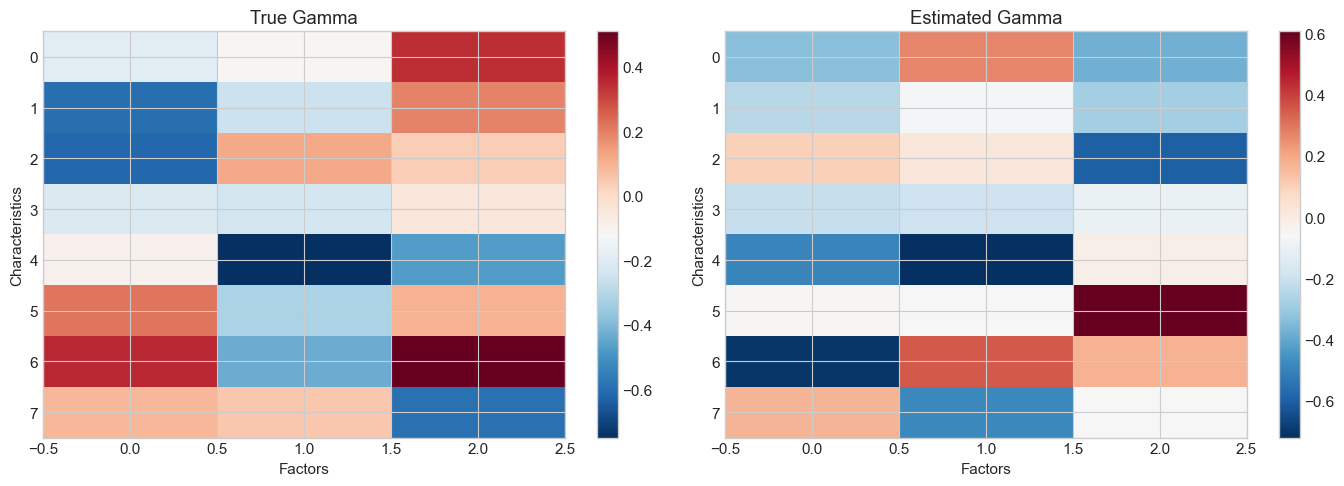

In [18]:
# Compare true vs estimated Gamma (accounting for rotation)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
im = ax.imshow(true_Gamma, aspect='auto', cmap='RdBu_r')
ax.set_xlabel('Factors')
ax.set_ylabel('Characteristics')
ax.set_title('True Gamma')
plt.colorbar(im, ax=ax)

ax = axes[1]
im = ax.imshow(Gamma_est, aspect='auto', cmap='RdBu_r')
ax.set_xlabel('Factors')
ax.set_ylabel('Characteristics')
ax.set_title('Estimated Gamma')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## 6. Prediction Analysis

Predictions shape: (120, 100)


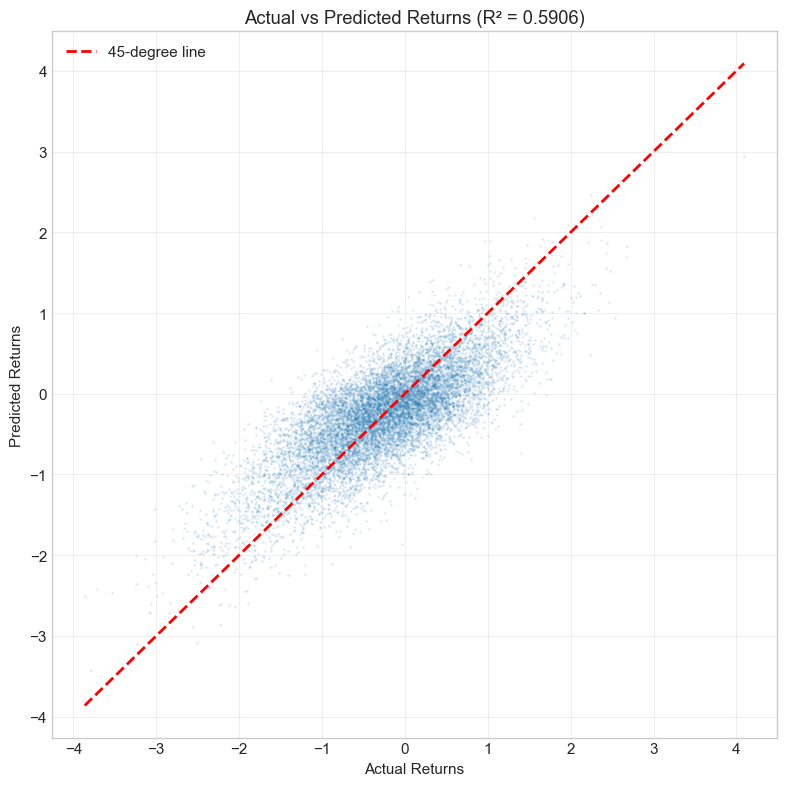

In [19]:
# Get predictions
preds = model.predict(Z, M)

print(f"Predictions shape: {preds.shape}")

# Scatter plot: actual vs predicted
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(rets.flatten(), preds.flatten(), alpha=0.1, s=1)
ax.plot([rets.min(), rets.max()], [rets.min(), rets.max()], 'r--', linewidth=2, label='45-degree line')
ax.set_xlabel('Actual Returns')
ax.set_ylabel('Predicted Returns')
ax.set_title(f'Actual vs Predicted Returns (R² = {r2:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

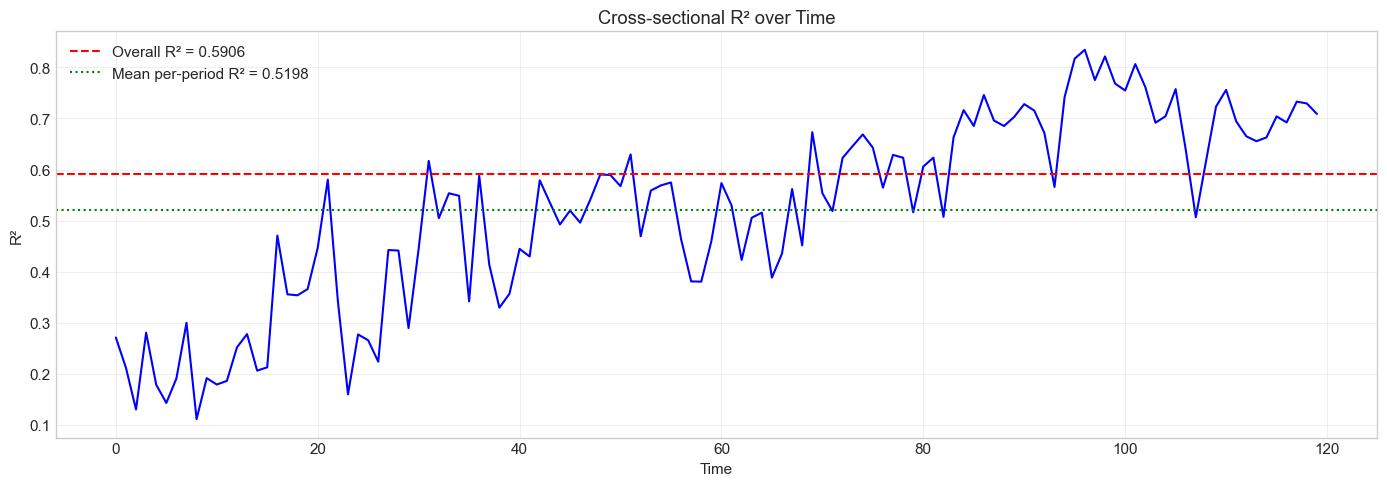

In [20]:
# Time series of R-squared
r2_ts = np.zeros(T)
for t in range(T):
    ss_res = np.sum((rets[t, :] - preds[t, :]) ** 2)
    ss_tot = np.sum((rets[t, :] - np.mean(rets[t, :])) ** 2)
    r2_ts[t] = 1 - ss_res / ss_tot if ss_tot > 0 else 0

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(r2_ts, 'b-', linewidth=1.5)
ax.axhline(y=r2, color='r', linestyle='--', label=f'Overall R² = {r2:.4f}')
ax.axhline(y=np.mean(r2_ts), color='g', linestyle=':', label=f'Mean per-period R² = {np.mean(r2_ts):.4f}')
ax.set_xlabel('Time')
ax.set_ylabel('R²')
ax.set_title('Cross-sectional R² over Time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Summary Statistics

In [21]:
# Summary
print("="*60)
print("HARD GIPCA SIMULATION RESULTS SUMMARY")
print("="*60)
print(f"\nData Dimensions:")
print(f"  T (time periods):     {T}")
print(f"  N (assets):           {N}")
print(f"  L (characteristics):  {L}")
print(f"  K (factors):          {K}")
print(f"  R (macro variables):  {R_total}")

print(f"\nModel Performance:")
print(f"  Overall R²:           {r2:.4f}")
print(f"  Mean per-period R²:   {np.mean(r2_ts):.4f}")
print(f"  Iterations:           {results['n_iterations']}")
print(f"  Final objective:      {history[-1]:.6f}")

print(f"\nParameter Recovery:")
print(f"  Grassmann distance:   {np.linalg.norm(principal_angles):.4f}")
print(f"  Principal angles (°): {np.round(np.degrees(principal_angles), 2)}")

print(f"\nFactor Recovery:")
print(f"  Mean |correlation|:   {np.mean(np.abs(np.diag(factor_corr))):.4f}")

print(f"\nConvergence:")
print(f"  Objective reduction:  {(1 - history[-1] / history[0]) * 100:.2f}%")
print(f"  Monotonic:            {'Yes' if n_increases == 0 else 'No'}")
print("="*60)

HARD GIPCA SIMULATION RESULTS SUMMARY

Data Dimensions:
  T (time periods):     120
  N (assets):           100
  L (characteristics):  8
  K (factors):          3
  R (macro variables):  5

Model Performance:
  Overall R²:           0.5906
  Mean per-period R²:   0.5198
  Iterations:           15
  Final objective:      29.741783

Parameter Recovery:
  Grassmann distance:   0.6904
  Principal angles (°): [ 0.76  5.75 39.13]

Factor Recovery:
  Mean |correlation|:   0.6097

Convergence:
  Objective reduction:  12.91%
  Monotonic:            Yes


In [22]:
# Display estimated Gamma
print("Estimated Gamma (Characteristics to Factor Loadings):")
print(results['Gamma'].round(4))

Estimated Gamma (Characteristics to Factor Loadings):
        Factor_1  Factor_2  Factor_3
char_0   -0.3370    0.2658   -0.3756
char_1   -0.2401   -0.0690   -0.2810
char_2    0.1010    0.0204   -0.6034
char_3   -0.2093   -0.1972   -0.1040
char_4   -0.4942   -0.7231   -0.0193
char_5   -0.0505   -0.0546    0.6086
char_6   -0.7067    0.3514    0.1743
char_7    0.1689   -0.4858   -0.0623


In [23]:
# Display estimated Lambda
print("Estimated Lambda (Macro to Factors Mapping):")
print(results['Lambda'].round(4))

Estimated Lambda (Macro to Factors Mapping):
         Factor_1  Factor_2  Factor_3
macro_0    0.2775   -0.5385   -0.2115
macro_1   -0.1939   -0.1487    0.2258
macro_2    0.8212    0.2938   -0.4590
macro_3    0.6036   -0.4964   -0.5352
macro_4   -0.6106   -1.0084    0.2436
